### Import libraries + read in CSV

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic_passengers.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Create the crosstab of Pclass x Survived

In [4]:
ct = pd.crosstab(df['Pclass'], df['Survived'])
ct

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


### Calculate the relative frequencies

In [5]:
ct_rel = pd.crosstab(df['Pclass'], df['Survived'], normalize = True)
ct_rel

Survived,0,1
Pclass,,
1,0.089787,0.152637
2,0.108866,0.097643
3,0.417508,0.133558


### Create the stacked barplot of the relative frequencies

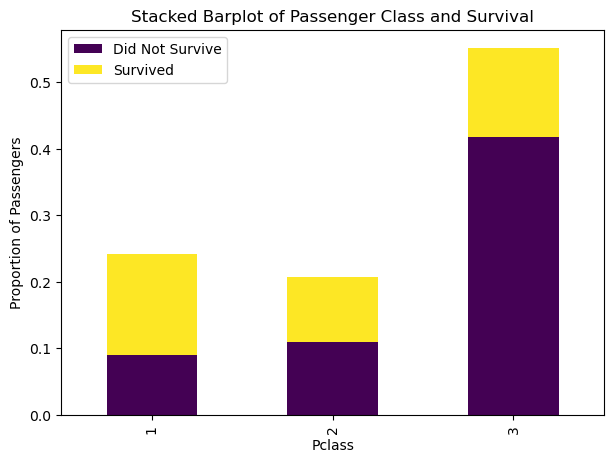

In [6]:
ct_rel.plot(kind='bar', stacked=True, figsize=(7,5), colormap='viridis')
plt.ylabel('Proportion of Passengers')
plt.title('Stacked Barplot of Passenger Class and Survival')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

### Percent of individuals within each passenger class who survived vs. perished

In [7]:
pct_within_class = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
pct_within_class

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


### Percent of individuals who survived/perished who were from each passenger class

In [8]:
pct_within_survival = pd.crosstab(df['Pclass'], df['Survived'], normalize='columns') * 100
pct_within_survival

Survived,0,1
Pclass,,
1,14.571949,39.766082
2,17.668488,25.438596
3,67.759563,34.795322


### Observations:
The analyses clearly show that passenger class played a major role in survival outcomes on the Titanic. First-class passengers had the highest survival rates, followed by second class, while third class had the lowest likelihood of surviving, a pattern that is visible in both the crostab counts and the stacked barplot. When looking at conditional proportions, we see that survival probability decreases steadily from first to third class, and that survivors were disproportionately from first class, whereas those who perished were largely from thrid class. Overall, the results highlight how strongly socioeconomic status influenced who lived and who did not.